# Example 2: Closed Surface — Ricci Flow + Embedding Comparison

Apply Ricci flow to a closed mesh to achieve uniform constant curvature,
then **compare two embedding strategies** for realising the target edge lengths:

- `optimization` — PyTorch / L-BFGS edge-length fitting
- `shape_from_metric` — local/global face-orientation + Poisson reconstruction (default)

The closed mesh is `demo/bunny.ply`, which has 102 vertices, 300 edges, and no boundary.
Its Euler characteristic is χ = 2, so the total Gaussian curvature is 4π.


In [1]:
import numpy as np
from ricci import (
    TriangleMesh, ricci_flow, embed, shape_from_metric,
    plot_mesh, plot_curvature, plot_convergence, plot_comparison,
)
from ricci.metric import DiscreteMetric
import matplotlib.pyplot as plt
%matplotlib inline


## 1. Load the closed mesh


TriangleMesh(V=102, E=300, F=200, boundary_V=0, chi=2)
Uniform target curvature per vertex: 0.1232 (= 0.0392π)


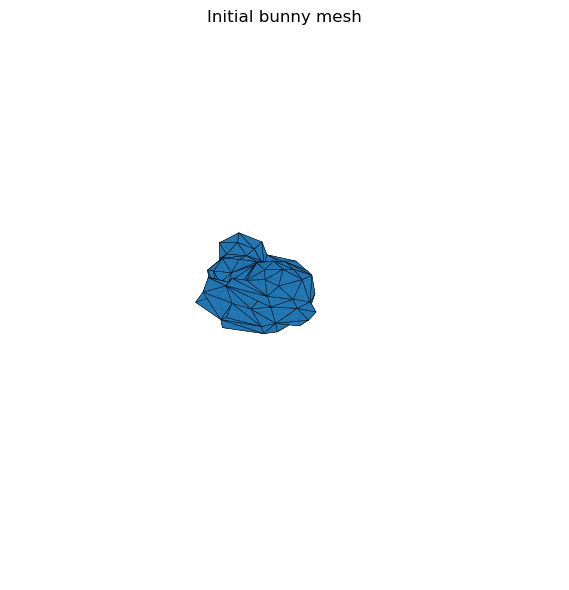

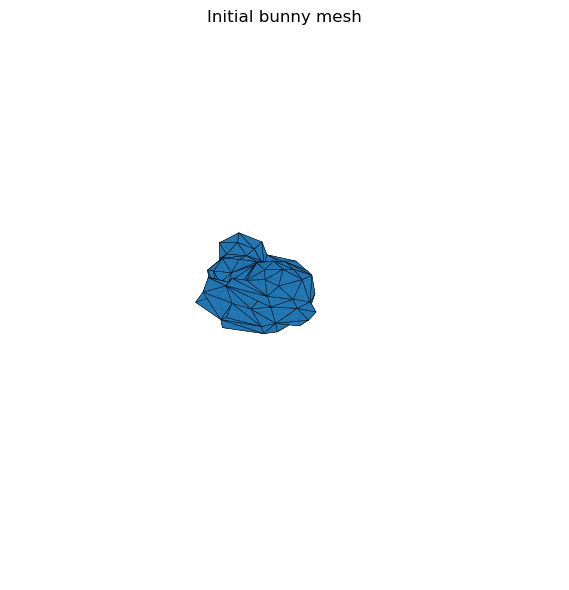

In [2]:
mesh = TriangleMesh.from_ply('demo/bunny.ply')
print(mesh)

target_K = 2 * np.pi * mesh.euler_characteristic / mesh.n_vertices
print(f'Uniform target curvature per vertex: {target_K:.4f} (= {target_K / np.pi:.4f}π)')

plot_mesh(mesh, show=True, title='Initial bunny mesh')


## 2. Ricci flow to constant curvature


In [3]:
result = ricci_flow(
    mesh,
    target_curvature=float(target_K),
    scheme='combinatorial',
    gtol=1e-5,
)

mae = np.abs(result.curvature - result.target_curvature).mean()
print(f'Curvature MAE: {mae:.2e}')


V=102, E=300, F=200, boundary_V=0, chi=2
specified_verts=102, free_verts=102
target total_K = 4.0000 pi
scale_factor = 1.000000
`gtol` termination condition is satisfied.
Function evaluations 8, initial cost 1.3959e+02, final cost 1.2131e-13, first-order optimality 1.10e-06.
curvature MAE = 1.399179e-08
Curvature MAE: 1.40e-08


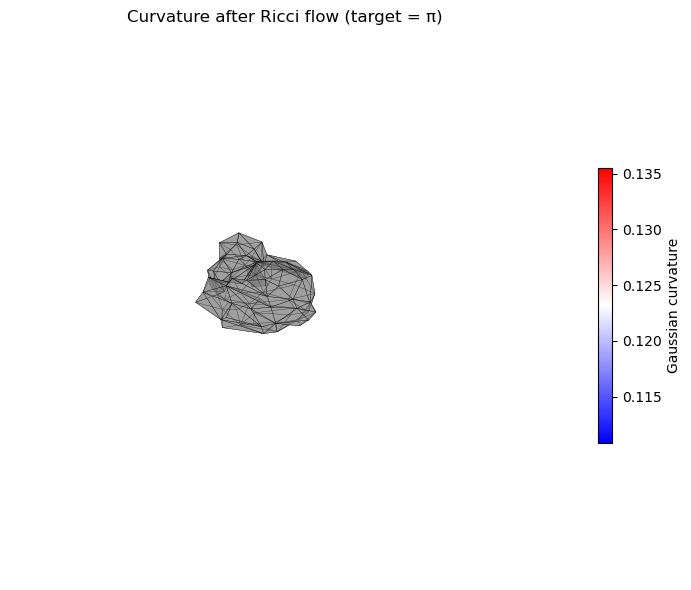

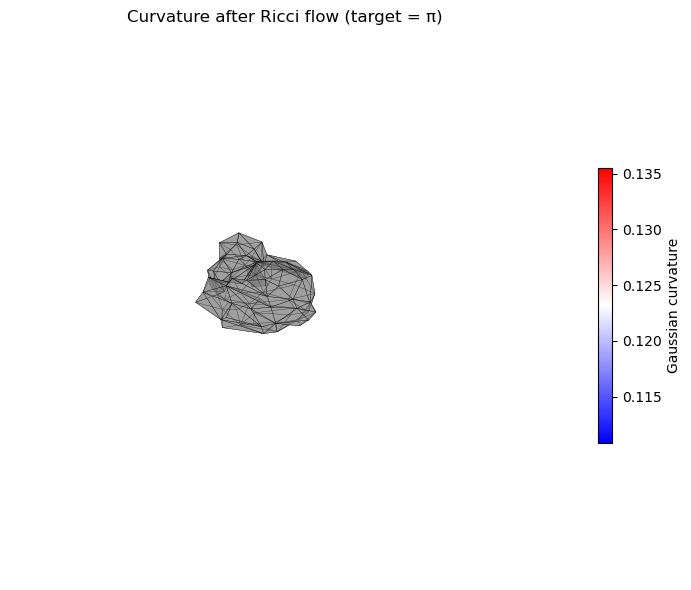

In [4]:
g_ricci = DiscreteMetric(mesh, result.edge_lengths)

plot_curvature(
    mesh, g_ricci.gaussian_curvature,
    vmin=result.target_curvature.min(),
    vmax=result.target_curvature.max(),
    show=True,
    title='Curvature after Ricci flow (target = π)',
)


## 3. Embedding comparison

Both paths receive the **same** target edge lengths from the Ricci flow output.

- `optimization` is the default iterative PyTorch / L-BFGS solver.
- `shape_from_metric` is the reference-inspired local/global reconstruction (default).


In [5]:
embedded_opt = embed(
    mesh, result.edge_lengths,
    method='optimization',
    lambda_boundary=0,
    gtol=1e-6,
    verbose=1,
)

embedded_sfm = embed(
    mesh, result.edge_lengths,
    method='shape_from_metric',
    lambda_boundary=0,
    gtol=1e-8,
    verbose=1,
)


Embedding: 102 vertices, 300 edges, fixed=0, device=cpu
  cost=1.72278510e-02, beta=1.000000, iters=2000
Shape-from-metric: 102 vertices, 200 faces, fixed=0
  cost=5.20635027e-08, beta=1.000000, iters=2000


### Side-by-side mesh comparison


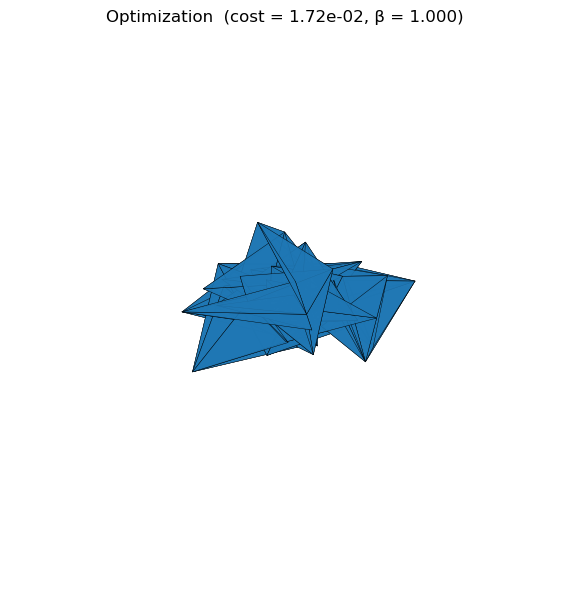

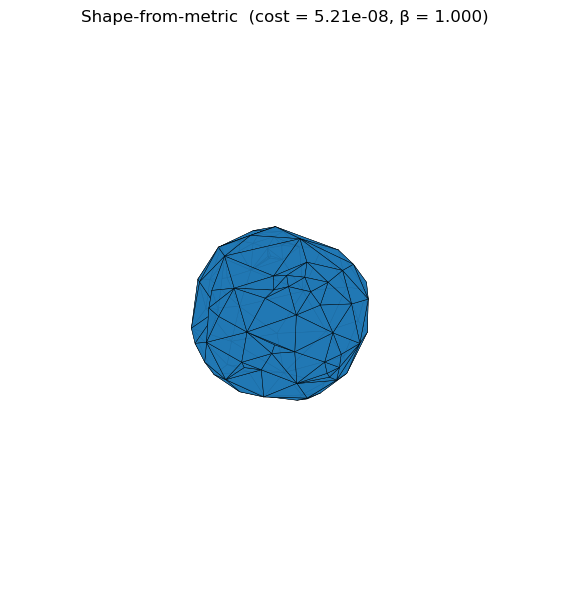

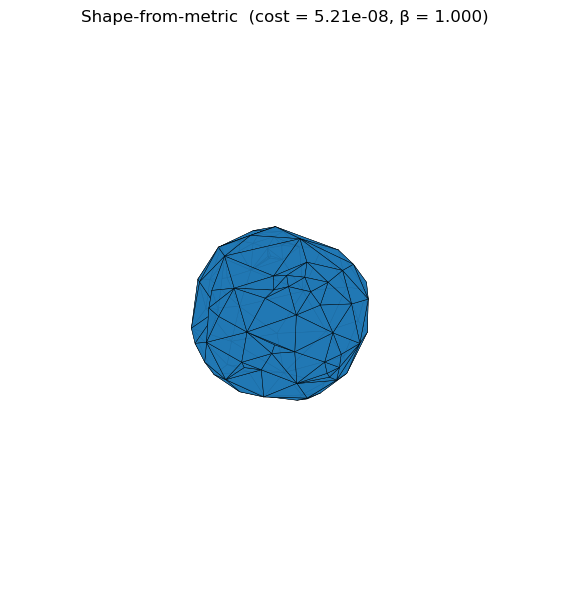

In [6]:
plot_mesh(embedded_opt.mesh, show=True,
          title=f'Optimization  (cost = {embedded_opt.cost:.2e}, β = {embedded_opt.scale_factor:.3f})')
plot_mesh(embedded_sfm.mesh, show=True,
          title=f'Shape-from-metric  (cost = {embedded_sfm.cost:.2e}, β = {embedded_sfm.scale_factor:.3f})')


### Curvature distributions


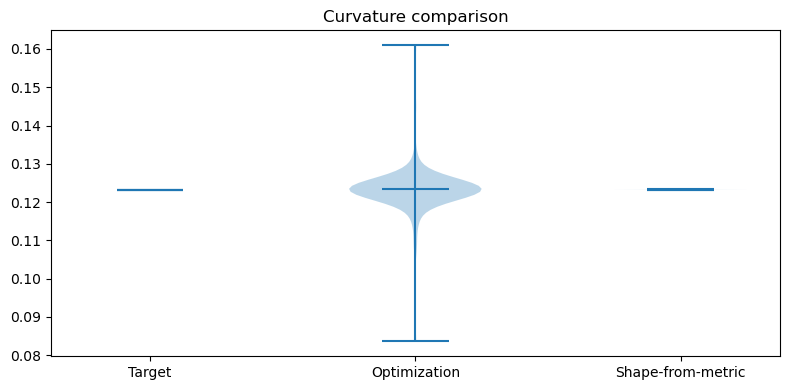

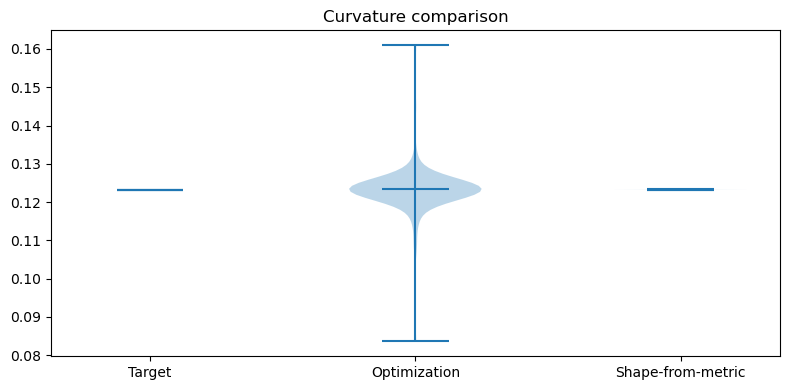

In [7]:
g_opt = DiscreteMetric(embedded_opt.mesh, embedded_opt.mesh.edge_lengths)
g_sfm = DiscreteMetric(embedded_sfm.mesh, embedded_sfm.mesh.edge_lengths)

plot_comparison(
    [result.target_curvature, g_opt.gaussian_curvature, g_sfm.gaussian_curvature],
    labels=['Target', 'Optimization', 'Shape-from-metric'],
    title='Curvature comparison',
    show=True,
)


### Convergence history


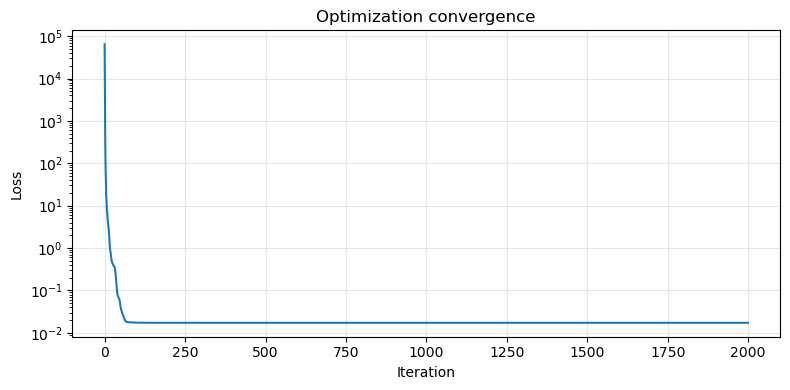

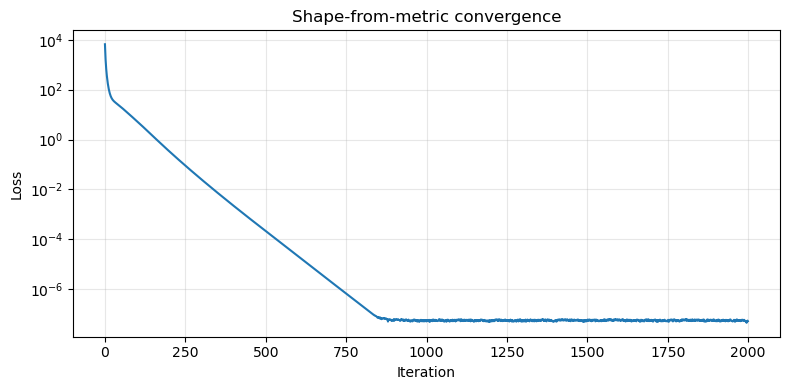

In [8]:
if embedded_opt.history:
    plot_convergence(embedded_opt.history, show=True,
                     title='Optimization convergence')
if len(embedded_sfm.history) > 1:
    plot_convergence(embedded_sfm.history, show=True,
                     title='Shape-from-metric convergence')


## 4. Summary


In [9]:
print('Method              Cost            Iters    Beta')
print('-' * 55)
print(f'Optimization        {embedded_opt.cost:.4e}   {len(embedded_opt.history):5d}     {embedded_opt.scale_factor:.4f}')
print(f'Shape-from-metric   {embedded_sfm.cost:.4e}   {len(embedded_sfm.history):5d}     {embedded_sfm.scale_factor:.4f}')

print()
print('Note: `shape_from_metric` keeps β = 1 because the metric itself fixes the scale.')
print('The `optimization` path may learn a global β if boundary anchors permit scaling.')


Method              Cost            Iters    Beta
-------------------------------------------------------
Optimization        1.7228e-02    2000     1.0000
Shape-from-metric   5.2064e-08    2000     1.0000

Note: `shape_from_metric` keeps β = 1 because the metric itself fixes the scale.
The `optimization` path may learn a global β if boundary anchors permit scaling.
